### dyngen绘制指标
（毫无复用性的代码hh）

以下代码只需运行一次

In [6]:
import scanpy as sc
adata_path = '/HDD1/xueweizhi/spvelo_data/simulate/simulate_dyngen/standard/general/dataset.h5ad'
adata = sc.read(adata_path)
cate_list = adata.obs['progress'].cat.categories.tolist()
cate_list

/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


['sA->sB', 'sB->sBmid', 'sBmid->sC', 'sBmid->sD', 'sC->sEndC', 'sD->sEndD']

In [7]:
import pickle as pkl

clusters_path = '../clusters/dyngen.pkl'
# dump clusters
with open(clusters_path, 'wb') as f:
    pkl.dump(cate_list, f)

共用的代码段

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = '../clusters/dyngen.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
dataset = 'simulate/dyngen'
datas = ['general/dataset', 'general/dataset_2d', 'general_0.1/dataset', 'general_0.1/dataset_2d']
data = 'general/dataset'

In [2]:
dataset = 'real/hsc_revised'

In [7]:
import pickle as pkl

cluster_edges = [('HSC', 'MEP-like'),
                 ('HSC', 'GMP-like'),
                 ('MEP-like', 'Ery'),
                 ('MEP-like', 'Bas'),
                 ('MEP-like', 'Meg'),
                 ('GMP-like', 'Mon'),
                 ('GMP-like', 'Bas'),
                 ('GMP-like', 'Neu'),]
cluster_edges_path = f'../cluster_edges/{dataset.removeprefix("real/").removesuffix("_revised")}.pkl'
with open(cluster_edges_path, 'wb') as f:
    pkl.dump(cluster_edges, f)


In [9]:
import pickle as pkl

cluster_edges_path = f'../cluster_edges/{dataset.removeprefix("real/").removesuffix("_revised")}.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = f'../clusters/{dataset.removeprefix("real/").removesuffix("_revised")}.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
clusters

['HSC', 'MEP-like', 'GMP-like', 'Ery', 'Bas', 'Mon', 'Neu', 'Meg']

In [4]:
import os

In [5]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo(avg)": "#17becf",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt(vj)": "#bcbd22"
}

**cbdir**: coord和umap分别画

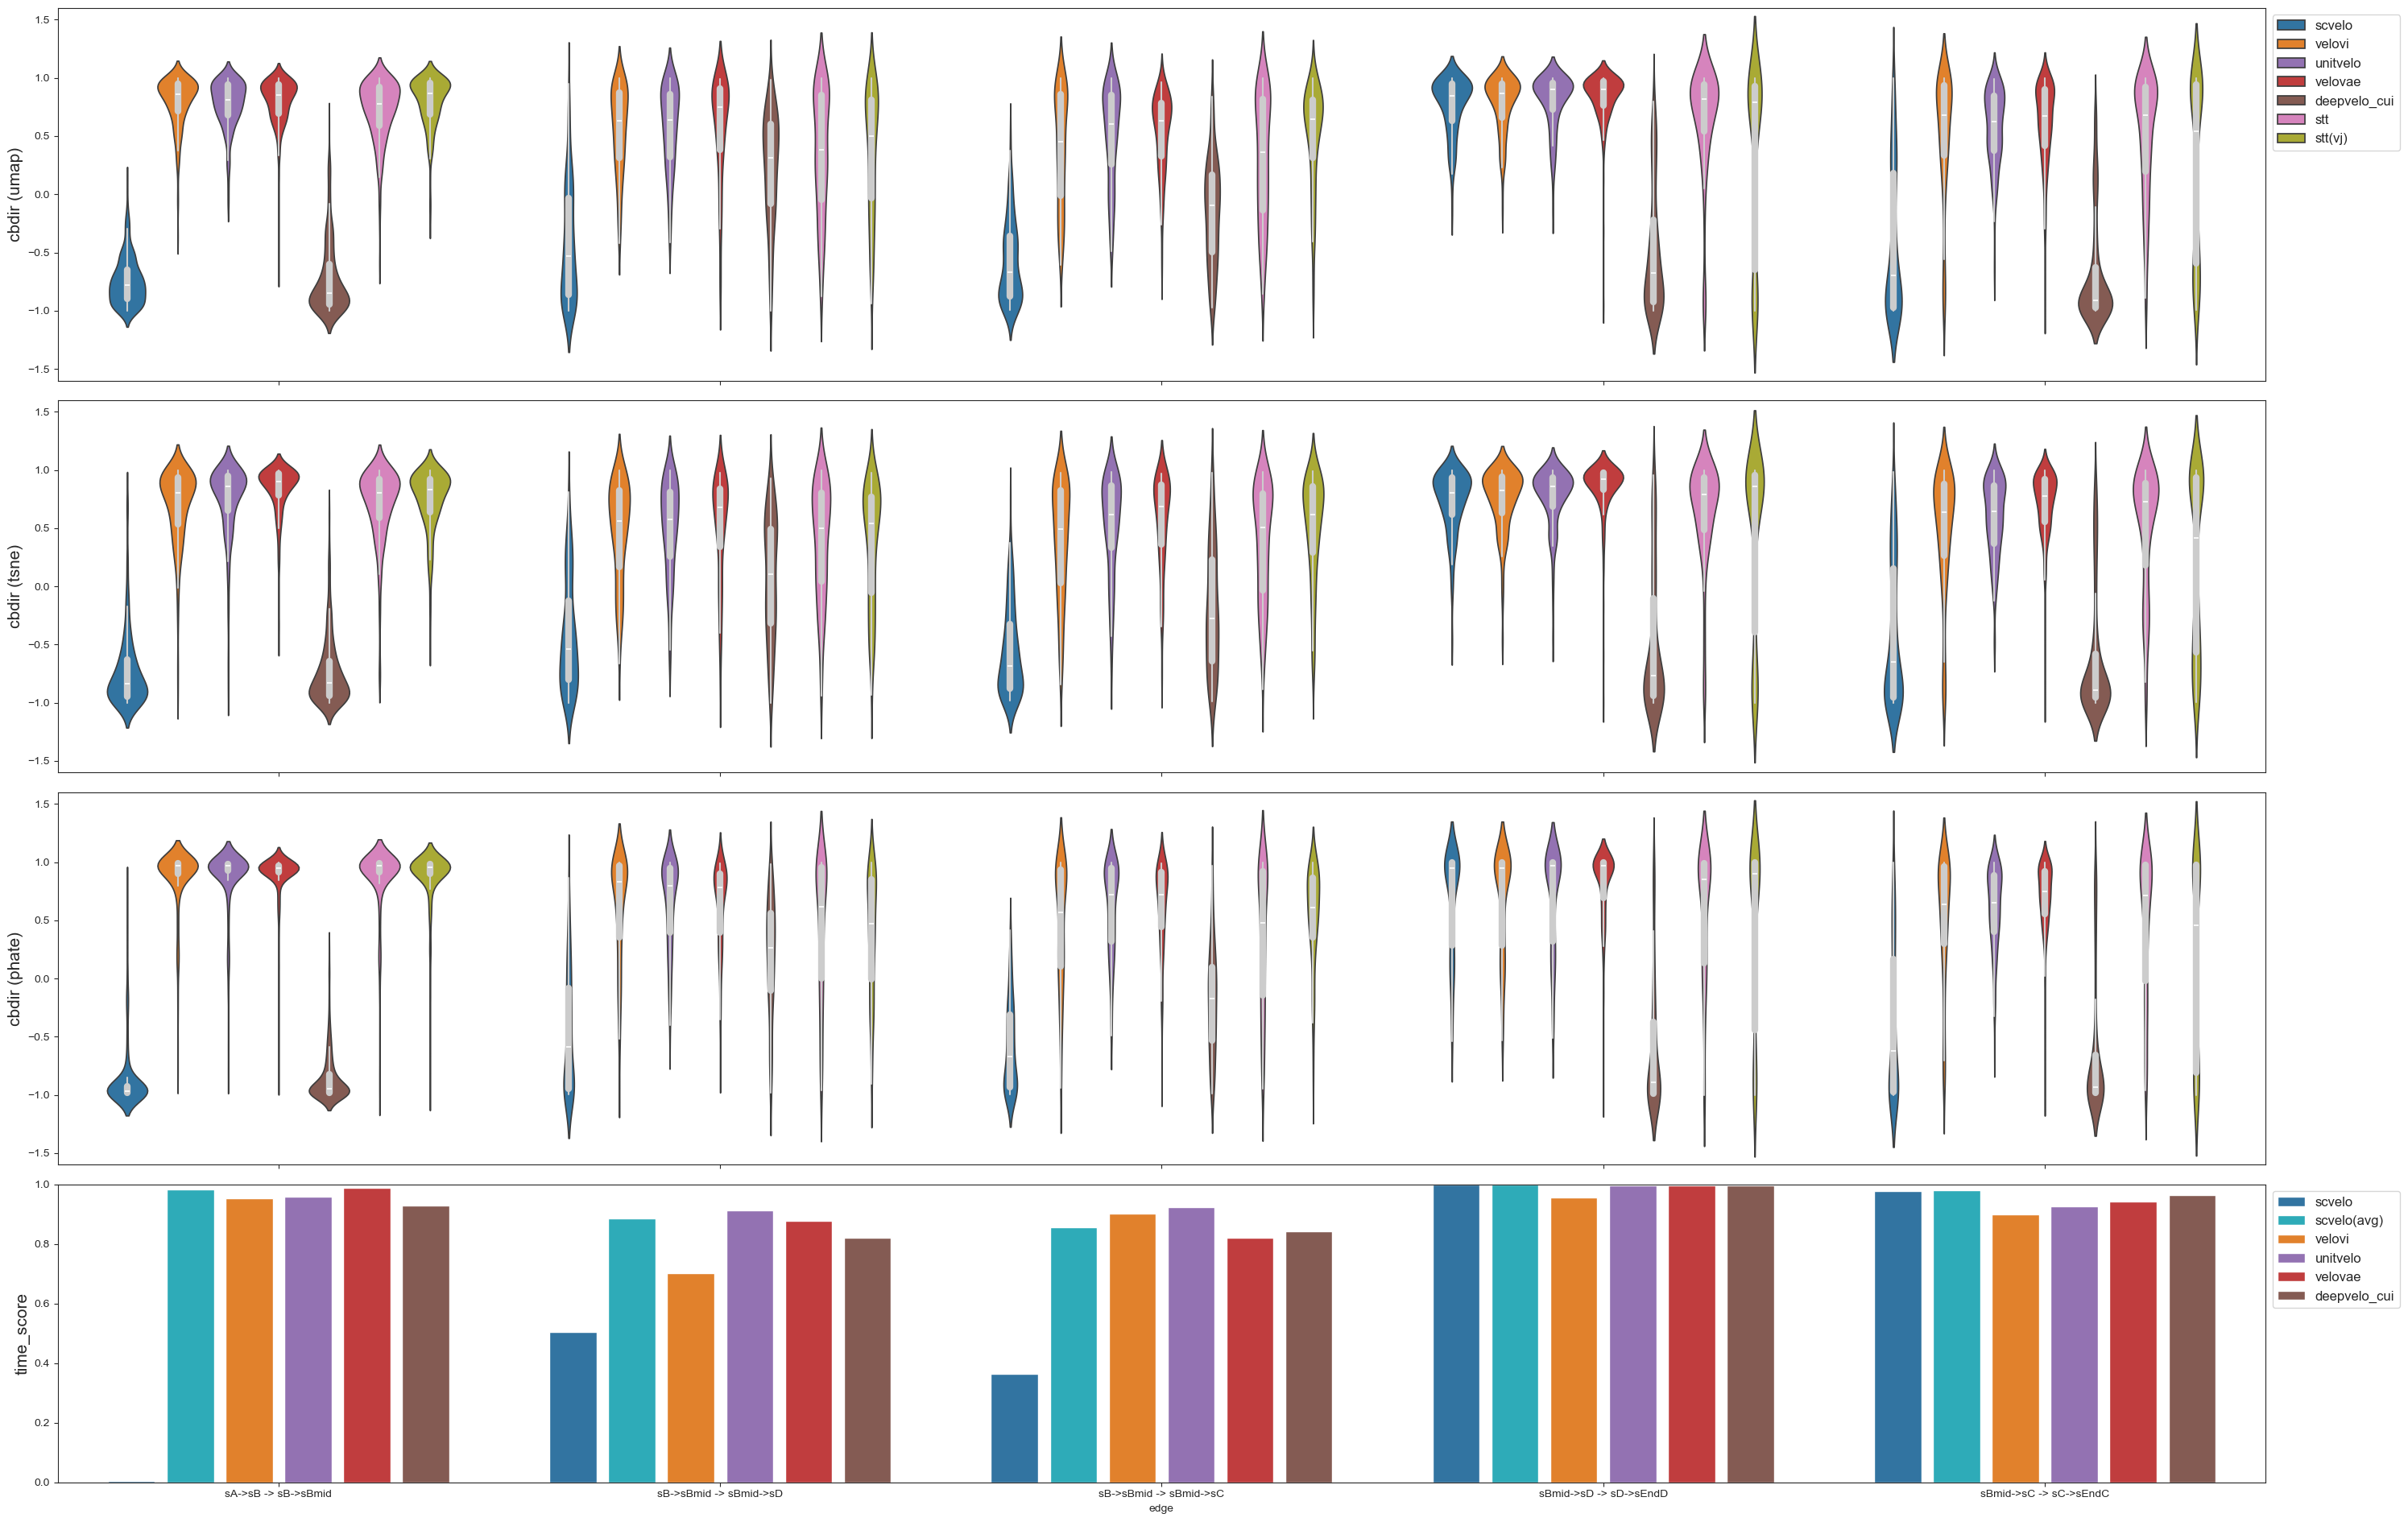

In [10]:
metric_name_cbdir = 'cbdir'
bases = ['umap', 'tsne', 'phate']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']

# for data in datas:
result_final = {}

for basis in bases:
    results = {}
    for cluster_edge in cluster_edges: 
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {}
        for model in models:
            model_name = model if model != 'scvelo' else f'{model}_dynamical'
            dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_cbdir}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pkl.load(f)
            if edge in metric.keys():
                result[model] = metric[edge]
            if model == 'stt':
                stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_cbdir}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    stt_metric = pkl.load(f)
                if edge in stt_metric.keys():
                    result['stt(vj)'] = stt_metric[edge]
        results[edge] = result
    
    # transform into long format
    result_long = []
    for edge, result in results.items():
        for model, metric in result.items():
            for value in metric:
                result_long.append({'edge': edge, 'model': model, metric_name_cbdir: value})
    df_long = pd.DataFrame(result_long)
    result_final[basis] = df_long

metric_name_time_score = 'time_score_edge'
basis = 'coord' # it does not matter
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui']

results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        metric_file = f'../logs/{model}/{dataset_name}/{data}/metric_{basis}_redo.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name_time_score}_pred_t_norm_{edge}'
        if idx_name in metric.index:
            t_score = metric.loc[idx_name, '0']
            t_score = float(t_score)
            result[model] = t_score
        if model == 'scvelo':
            scv_idx_name = f'{metric_name_time_score}_fit_t_norm_{edge}'
            if scv_idx_name in metric.index:
                t_score = metric.loc[scv_idx_name, '0']
                t_score = float(t_score)
                result['scvelo(avg)'] = t_score
    results[edge] = result

# transform into long format
result_long = []
for edge, result in results.items():
    for model, metric in result.items():
        result_long.append({'edge': edge, 'model': model, metric_name_time_score: metric})
df_long = pd.DataFrame(result_long)

save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
os.makedirs(save_dir, exist_ok=True)

# subplots
n_rows = len(bases) + 1
fig, axs = plt.subplots(len(bases) + 1, 1, figsize=(30, 5 * len(bases) + 4), sharex=True, gridspec_kw={'height_ratios': [5] * len(bases) + [4]})
i = 0
for basis, df in result_final.items():
    sns.violinplot(x='edge', y=metric_name_cbdir, hue='model', data=df, palette=model_colors, ax=axs[i], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
    axs[i].set_ylim(-1.6, 1.6)
    axs[i].set_ylabel(f'{metric_name_cbdir} ({basis})', fontsize=15)
    if i == 0:
        # Adjust the legend to be outside the plot
        axs[i].legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
    else:
        axs[i].get_legend().remove()
    i += 1
sns.barplot(x='edge', y=metric_name_time_score, hue='model', data=df_long, palette=model_colors, ax=axs[i], width=0.8, gap=0.2)
axs[i].set_ylim(0, 1)
axs[i].set_ylabel(metric_name_time_score.replace('_edge', ''), fontsize=15)
# Adjust the legend to be outside the plot
axs[i].legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/cbdir_and_tscore.svg')
plt.show()

# for key, value in results.items():
#     df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
#     plt.figure(figsize=(8, 6))
#     sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
#     plt.ylim(-1.6, 1.6) # remember to change this
#     plt.title(key)
#     plt.savefig(f'{save_dir}/{metric_name}_{basis}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
#     plt.show()

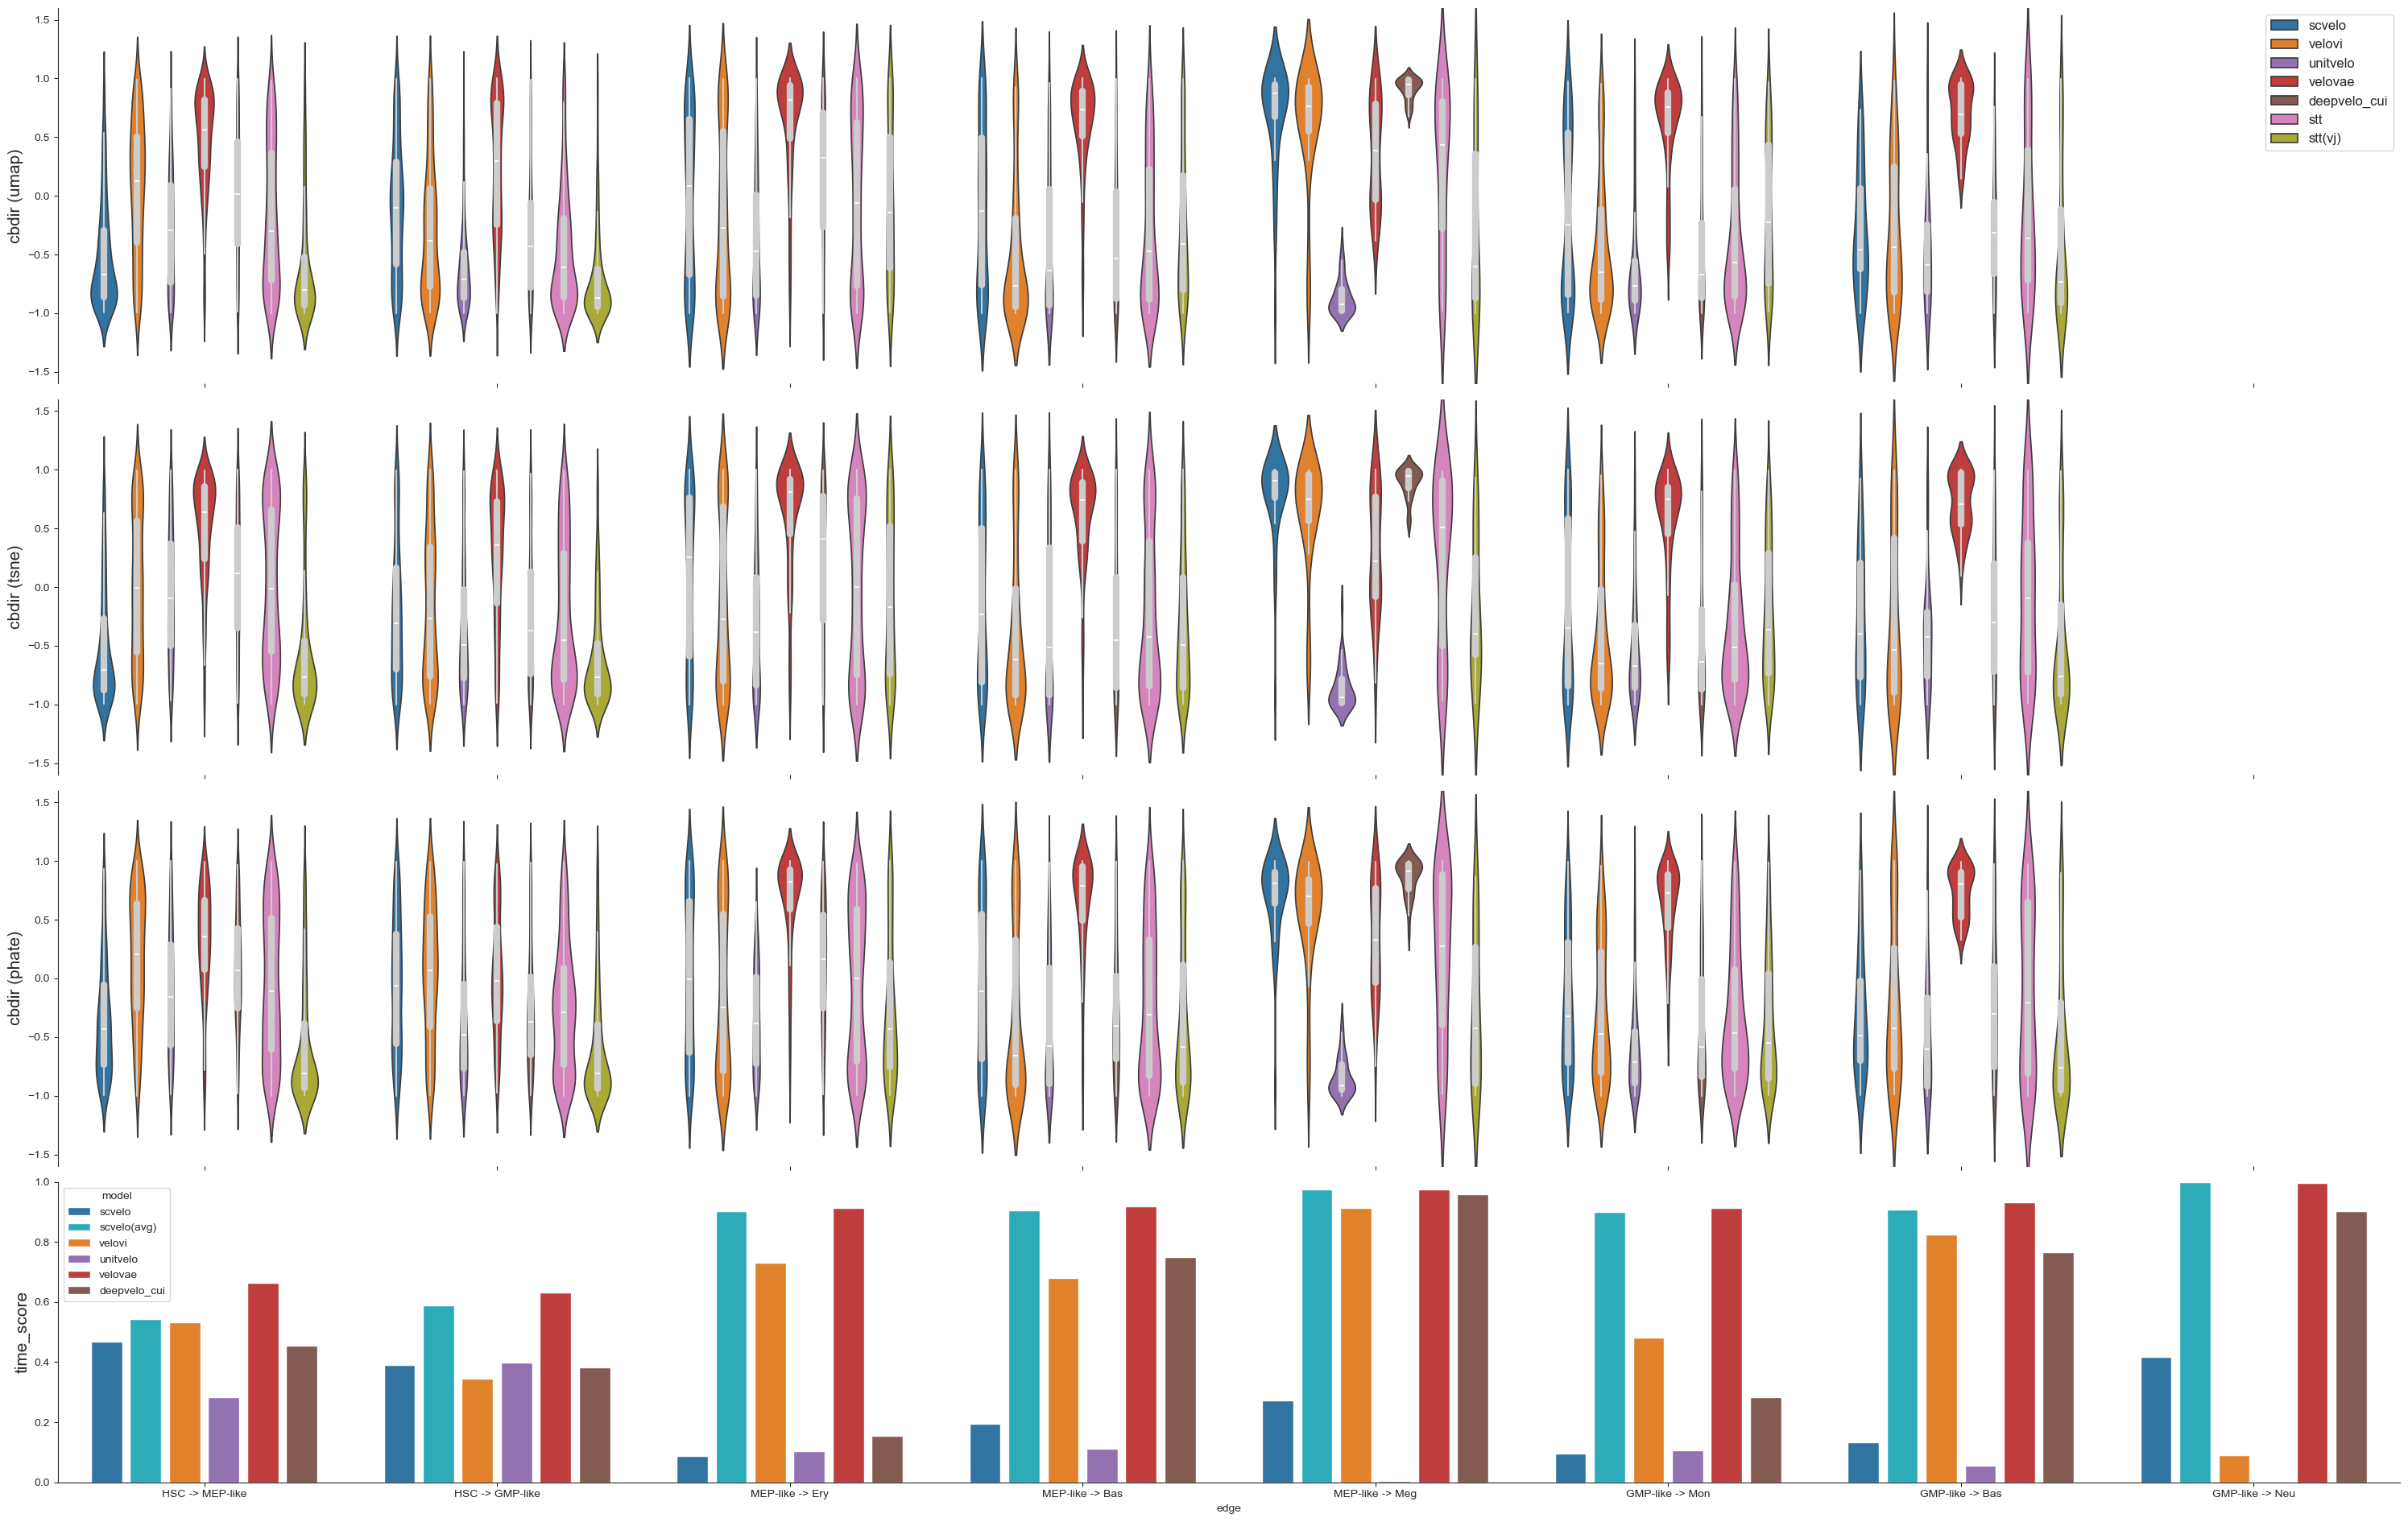

In [16]:
metric_name_cbdir = 'cbdir'
bases = ['umap', 'tsne', 'phate']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']

# for data in datas:
result_final = {}

for basis in bases:
    results = {}
    for cluster_edge in [edge for edge in cluster_edges if edge != ('GMP-like', 'Neu')]: 
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {}
        for model in models:
            model_name = model if model != 'scvelo' else f'{model}_dynamical'
            # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            # metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_cbdir}_{basis}_{model_name}_velocity.pkl'
            metric_file = f'../logs/{model}/{dataset}/{metric_name_cbdir}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pkl.load(f)
            if edge in metric.keys():
                result[model] = metric[edge]
            if model == 'stt':
                # stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_cbdir}_{basis}_vj.pkl'
                stt_metric_file = f'../logs/{model}/{dataset}/{metric_name_cbdir}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    stt_metric = pkl.load(f)
                if edge in stt_metric.keys():
                    result['stt(vj)'] = stt_metric[edge]
        results[edge] = result
    
    # transform into long format
    result_long = []
    for edge, result in results.items():
        for model, metric in result.items():
            for value in metric:
                result_long.append({'edge': edge, 'model': model, metric_name_cbdir: value})
    df_long = pd.DataFrame(result_long)
    result_final[basis] = df_long

metric_name_time_score = 'time_score_edge'
basis = 'umap' # it does not matter
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui']

results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        # metric_file = f'../logs/{model}/{dataset_name}/{data}/metric_{basis}_redo.csv'
        metric_file = f'../logs/{model}/{dataset}/metric_{basis}_redo.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name_time_score}_pred_t_norm_{edge}'
        if idx_name in metric.index:
            t_score = metric.loc[idx_name, '0']
            t_score = float(t_score)
            result[model] = t_score
        if model == 'scvelo':
            scv_idx_name = f'{metric_name_time_score}_fit_t_norm_{edge}'
            if scv_idx_name in metric.index:
                t_score = metric.loc[scv_idx_name, '0']
                t_score = float(t_score)
                result['scvelo(avg)'] = t_score
    results[edge] = result

# transform into long format
result_long = []
for edge, result in results.items():
    for model, metric in result.items():
        result_long.append({'edge': edge, 'model': model, metric_name_time_score: metric})
df_long = pd.DataFrame(result_long)

# save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
save_dir = f'../results/result_22feb/{dataset.removeprefix("real/").removesuffix("_revised")}'
os.makedirs(save_dir, exist_ok=True)

# subplots
n_rows = len(bases) + 1
fig, axs = plt.subplots(len(bases) + 1, 1, figsize=(30, 5 * len(bases) + 4), sharex=True, gridspec_kw={'height_ratios': [5] * len(bases) + [4]})
i = 0
for basis, df in result_final.items():
    sns.violinplot(x='edge', y=metric_name_cbdir, hue='model', data=df, palette=model_colors, ax=axs[i], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
    axs[i].set_ylim(-1.6, 1.6)
    axs[i].set_ylabel(f'{metric_name_cbdir} ({basis})', fontsize=15)
    if i == 0:
        # Adjust the legend to be outside the plot
        axs[i].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize=12)
    else:
        axs[i].get_legend().remove()
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    i += 1
sns.barplot(x='edge', y=metric_name_time_score, hue='model', data=df_long, palette=model_colors, ax=axs[i], width=0.8, gap=0.2)
axs[i].spines['top'].set_visible(False)
axs[i].spines['right'].set_visible(False)
axs[i].set_ylim(0, 1)
axs[i].set_ylabel(metric_name_time_score.replace('_edge', ''), fontsize=15)
# Adjust the legend to be outside the plot
# axs[i].legend(bbox_to_anchor=(1, 1), loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/cbdir_and_tscore.svg')
plt.show()

**k-cbdir**: coord和umap分别画

In [18]:
import re
import ast

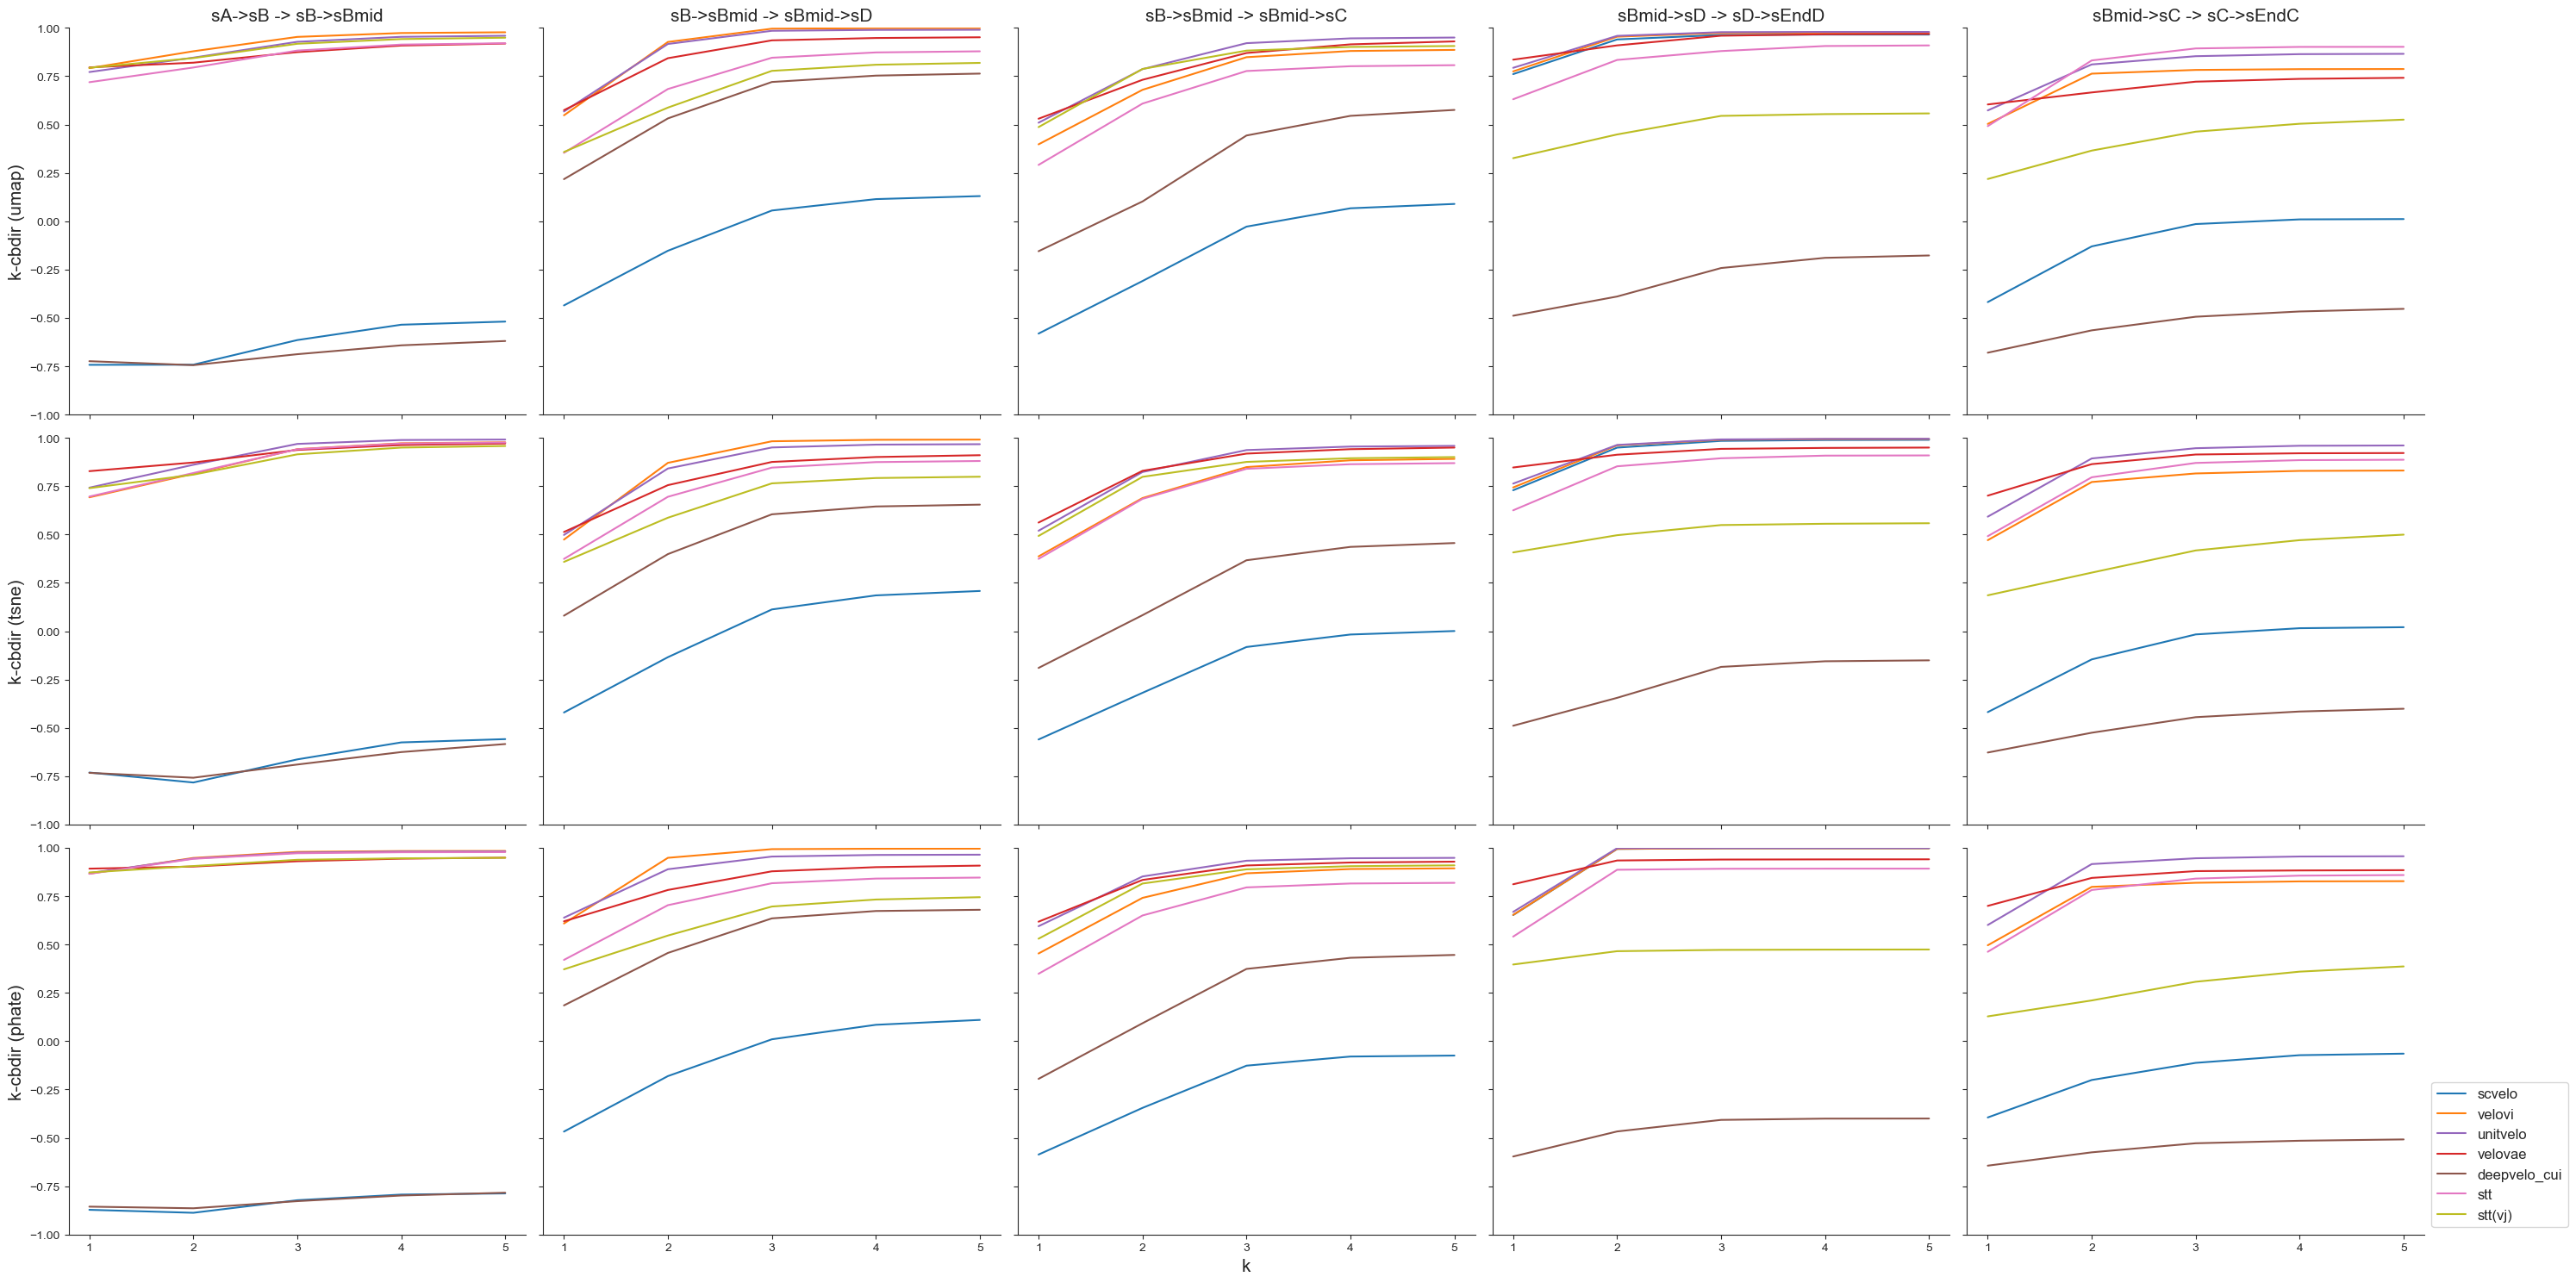

In [8]:
k = 5
metric_name = 'gen_cbdir_edge'
bases = ['umap', 'tsne', 'phate']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
# for data in datas:
result_final = {}
for basis in bases:
    results = {}
    for cluster_edge in cluster_edges:
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {'k': range(1, k+1)}
        for model in models: 
            model_name = model if model != 'scvelo' else 'scvelo_dynamical'
            dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            metric_file = f'../logs/{model}/{dataset_name}/{data}/metric_{basis}_redo.csv'
            metric = pd.read_csv(metric_file, index_col=0)
            idx_name = f'{metric_name}_{model_name}_velocity_{edge}'
            if idx_name in metric.index:
                cbdir = metric.loc[idx_name, '0']
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[model] = cbdir
            if model == 'stt': 
                stt_idx_name = f'{metric_name}_vj_{edge}'
                if stt_idx_name in metric.index:
                    cbdir = metric.loc[stt_idx_name, '0']
                    if 'nan' not in cbdir:
                        cbdir = re.sub(r'\s+', ', ', cbdir)
                        cbdir = ast.literal_eval(cbdir)
                        result['stt(vj)'] = cbdir
        results[edge] = result
    result_final[basis] = results

save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
os.makedirs(save_dir, exist_ok=True)

# subplots
n_rows = len(bases)
n_cols = len(cluster_edges)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharex=True, sharey=True)
for i, (basis, results) in enumerate(result_final.items()):
    for j, (edge, result) in enumerate(results.items()):
        df = pd.DataFrame(result).melt(id_vars='k', var_name='model', value_name=metric_name.removesuffix('_edge'))
        sns.lineplot(data=df, x='k', y=metric_name.removesuffix('_edge'), hue='model', palette=model_colors, ax=axs[i, j])
        axs[i, j].spines['right'].set_visible(False)
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].set_ylim(-1, 1)
        axs[i, j].set_xticks(range(1, k+1))
        # set row titles and column titles
        if j == 0:
            axs[i, j].set_ylabel(f'k-cbdir ({basis})', fontsize=15)
        if i == 0:
            axs[i, j].set_title(edge, fontsize=15)
        # only show x-axis label for the last row middle plot
        if i == n_rows - 1 and j == n_cols // 2:
            axs[i, j].set_xlabel('k', fontsize=15)
        else:
            axs[i, j].set_xlabel('')
        axs[i, j].get_legend().remove()
# global legend
handles, labels = axs[0, 0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0), fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/gen-cbdir.svg')
plt.show()

# for key, value in results.items():
#     df = pd.DataFrame(value).melt(id_vars='k', var_name='model', value_name=metric_name)
#     plt.figure(figsize=(8, 6))
#     sns.lineplot(data=df, x='k', y=metric_name, hue='model', palette=model_colors)
#     plt.ylim(-0.8, 1) # remember to change this
#     plt.xticks(range(1, k+1))
#     plt.title(key)
#     plt.savefig(f'{save_dir}/{metric_name}_{basis}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
#     plt.show()

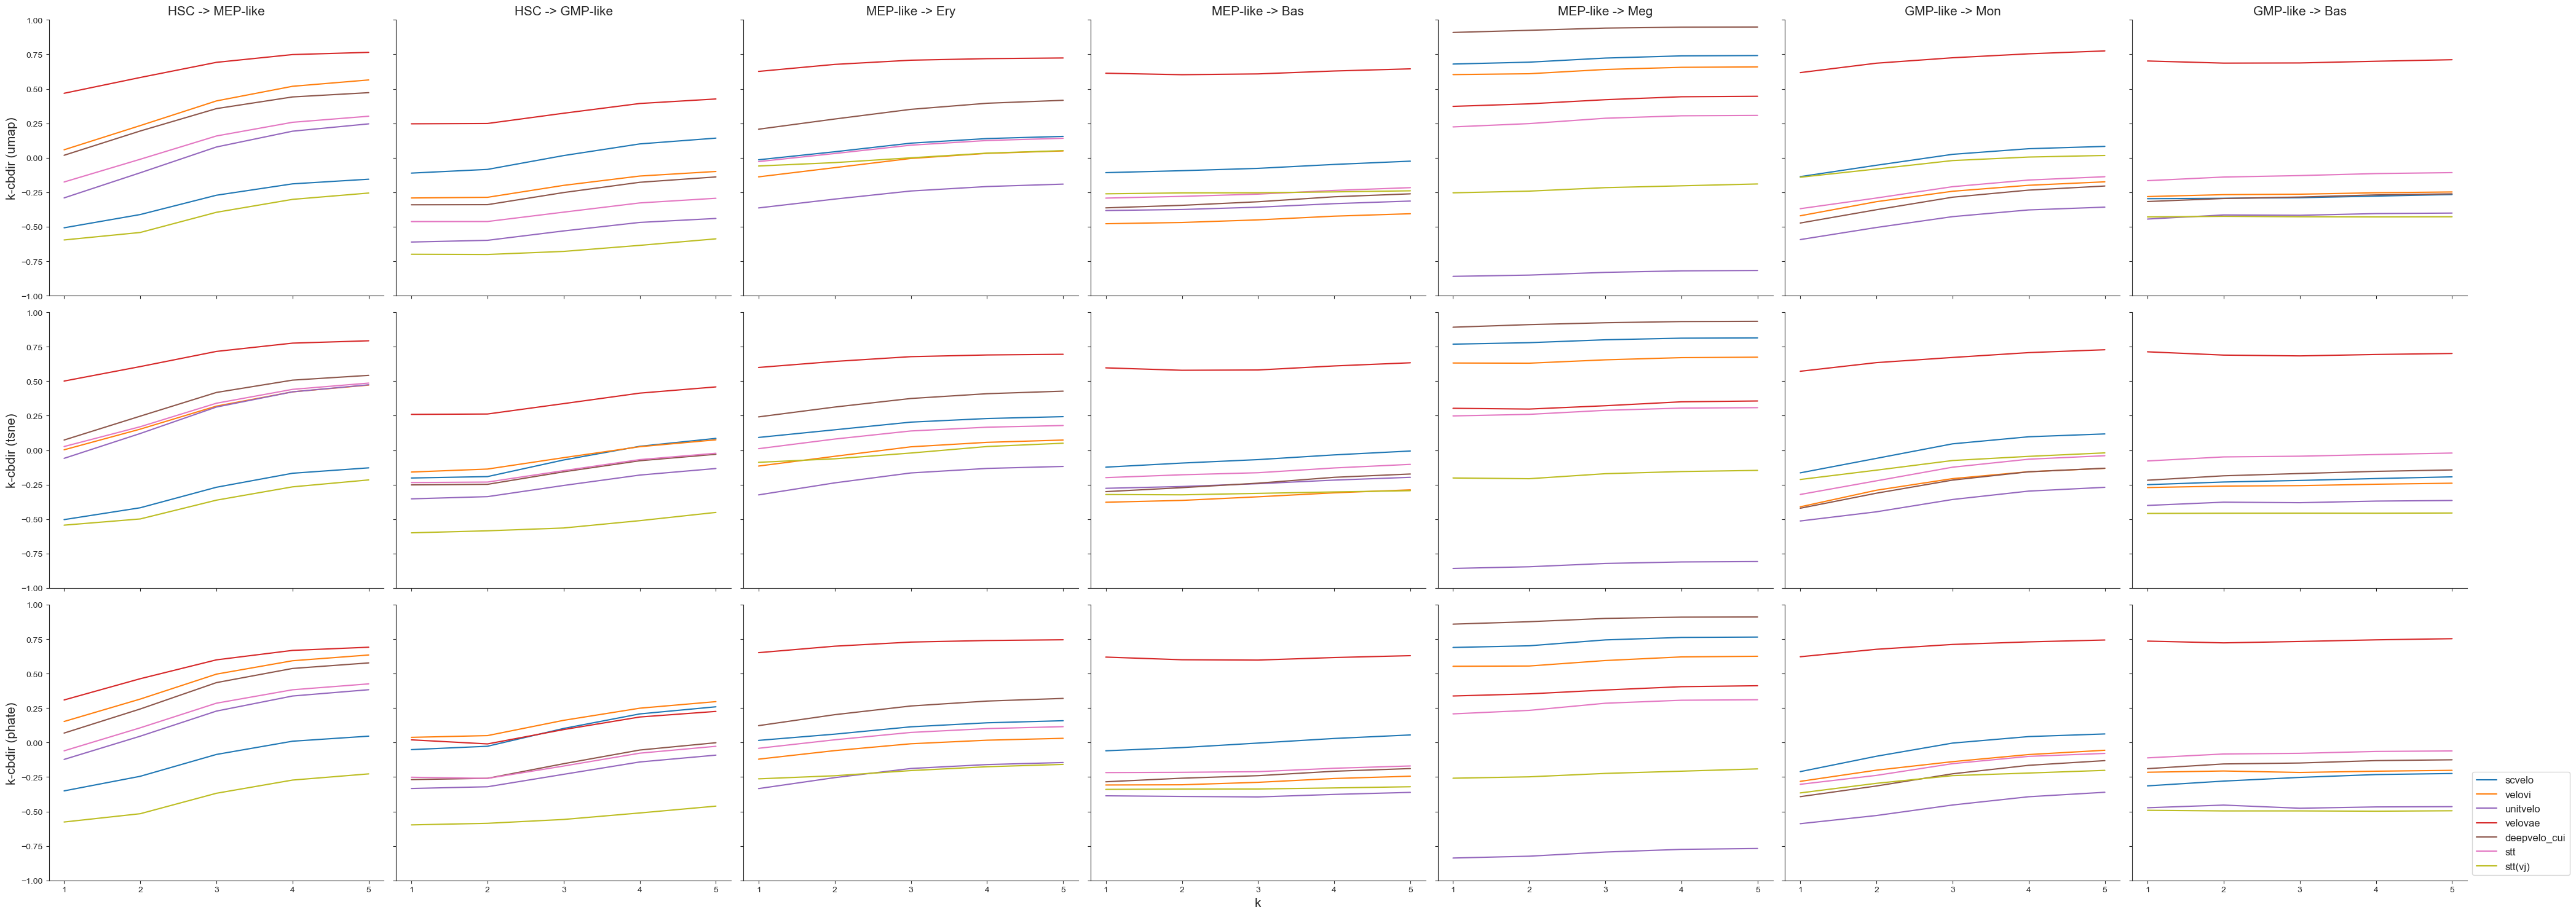

In [23]:
k = 5
metric_name = 'gen_cbdir_edge'
bases = ['umap', 'tsne', 'phate']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
# for data in datas:
result_final = {}
for basis in bases:
    results = {}
    for cluster_edge in [edge for edge in cluster_edges if edge != ('GMP-like', 'Neu')]: 
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {'k': range(1, k+1)}
        for model in models: 
            model_name = model if model != 'scvelo' else 'scvelo_dynamical'
            # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            # metric_file = f'../logs/{model}/{dataset_name}/{data}/metric_{basis}_redo.csv'
            metric_file = f'../logs/{model}/{dataset}/metric_{basis}_redo.csv'
            metric = pd.read_csv(metric_file, index_col=0)
            idx_name = f'{metric_name}_{model_name}_velocity_{edge}'
            if idx_name in metric.index:
                cbdir = metric.loc[idx_name, '0']
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'(?<=\d)\s+(?=\d|-)', ', ', cbdir)
                    cbdir = re.sub(r'(?<=\[)\s+(?=\d|-)', '', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[model] = cbdir
            if model == 'stt': 
                stt_idx_name = f'{metric_name}_vj_{edge}'
                if stt_idx_name in metric.index:
                    cbdir = metric.loc[stt_idx_name, '0']
                    if 'nan' not in cbdir:
                        cbdir = re.sub(r'(?<=\d)\s+(?=\d|-)', ', ', cbdir)
                        cbdir = re.sub(r'(?<=\[)\s+(?=\d|-)', '', cbdir)
                        cbdir = ast.literal_eval(cbdir)
                        result['stt(vj)'] = cbdir
        results[edge] = result
    result_final[basis] = results

# save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
# os.makedirs(save_dir, exist_ok=True)

# subplots
n_rows = len(bases)
n_cols = len(cluster_edges) - 1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharex=True, sharey=True)
for i, (basis, results) in enumerate(result_final.items()):
    for j, (edge, result) in enumerate(results.items()):
        df = pd.DataFrame(result).melt(id_vars='k', var_name='model', value_name=metric_name.removesuffix('_edge'))
        sns.lineplot(data=df, x='k', y=metric_name.removesuffix('_edge'), hue='model', palette=model_colors, ax=axs[i, j])
        axs[i, j].spines['right'].set_visible(False)
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].set_ylim(-1, 1)
        axs[i, j].set_xticks(range(1, k+1))
        # set row titles and column titles
        if j == 0:
            axs[i, j].set_ylabel(f'k-cbdir ({basis})', fontsize=15)
        if i == 0:
            axs[i, j].set_title(edge, fontsize=15)
        # only show x-axis label for the last row middle plot
        if i == n_rows - 1 and j == n_cols // 2:
            axs[i, j].set_xlabel('k', fontsize=15)
        else:
            axs[i, j].set_xlabel('')
        axs[i, j].get_legend().remove()
# global legend
handles, labels = axs[0, 0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0), fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/gen-cbdir.svg')
plt.show()

**iccoh**: 不分basis

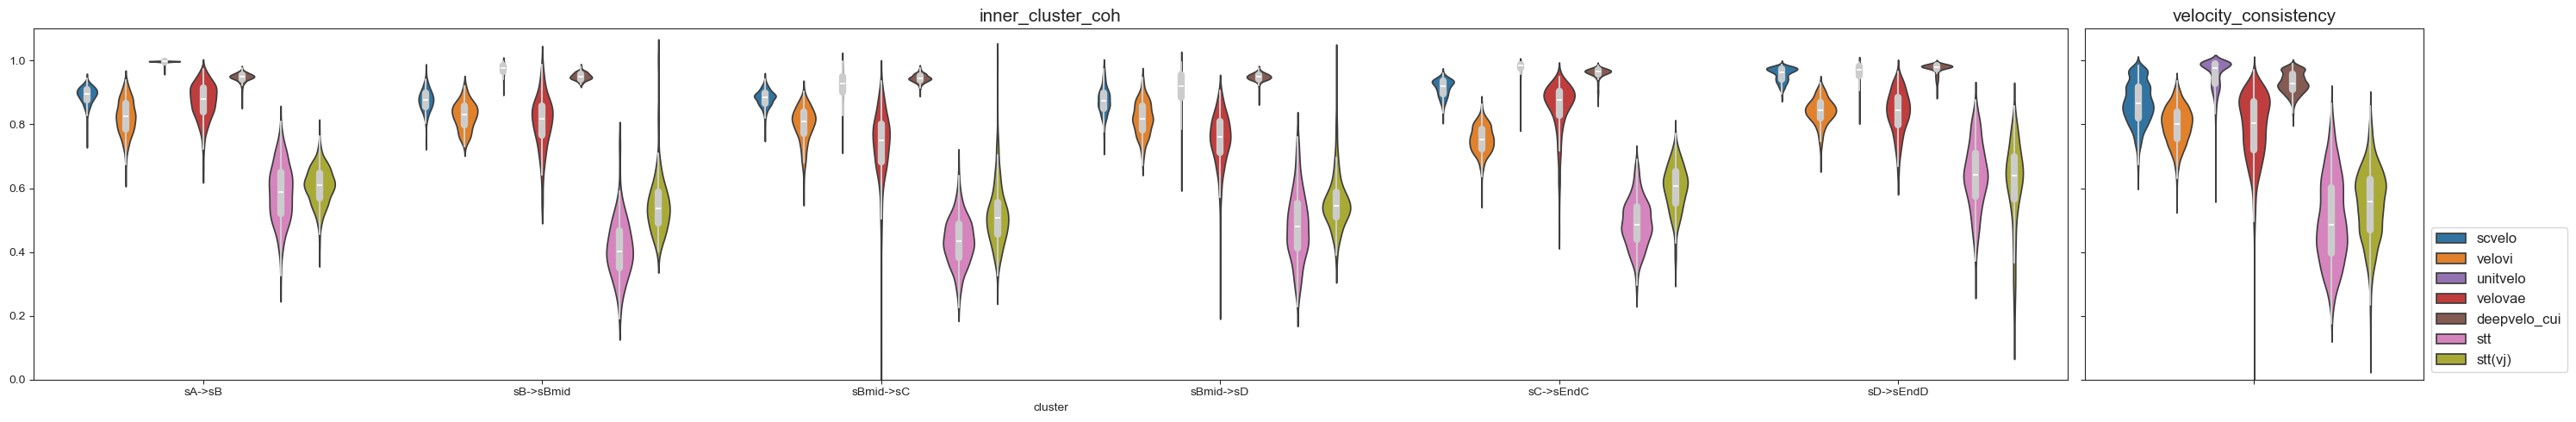

In [9]:
metric_name_iccoh = 'inner_cluster_coh'
basis = 'umap' # it does not matter
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']

# for data in datas:
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_iccoh}_{basis}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        result[model] = metric[cluster]
        if model == 'stt':
            dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_iccoh}_{basis}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
    results[cluster] = result

# transform into long format
result_long = []
for cluster, result in results.items():
    for model, metric in result.items():
        for value in metric:
            result_long.append({'cluster': cluster, 'model': model, metric_name_iccoh: value})
df_long = pd.DataFrame(result_long)

metric_name_v_consist = 'velocity_consistency'
result = {}
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
    metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_v_consist}_{basis}_{model_name}_velocity.pkl'
    with open(metric_file, 'rb') as f:
        metric = pkl.load(f)
    result[model] = metric
    if model == 'stt':
        dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_v_consist}_{basis}_vj.pkl'
        with open(stt_metric_file, 'rb') as f:
            stt_metric = pkl.load(f)
        result['stt(vj)'] = stt_metric

save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
os.makedirs(save_dir, exist_ok=True)

# subplots
n_cols = 2
fig, axs = plt.subplots(1, n_cols, figsize=(30, 5), gridspec_kw={'width_ratios': [6, 1]}, sharey=True)
sns.violinplot(x='cluster', y=metric_name_iccoh, hue='model', data=df_long, palette=model_colors, ax=axs[0], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
axs[0].set_ylim(0, 1.1)
axs[0].set_title(metric_name_iccoh, fontsize=15)
# remove y-axis label
axs[0].set_ylabel('')
# remove legend
axs[0].get_legend().remove()
sns.violinplot(y=metric_name_v_consist, hue='model', data=pd.DataFrame(result).melt(var_name='model', value_name=metric_name_v_consist), palette=model_colors, ax=axs[1], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
axs[1].set_ylim(0, 1.1)
axs[1].set_title(metric_name_v_consist, fontsize=15)
# remove y-axis label
axs[1].set_ylabel('')
# remove legend
axs[1].get_legend().remove()
# Adjust the legend to be outside the plot
handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0), fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/iccoh_and_vconsist.svg')
plt.show()

# for key, value in results.items():
#     df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
#     plt.figure(figsize=(8, 6))
#     sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
#     plt.ylim(0, 1.1) # remember to change this
#     plt.title(key)
#     plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
#     plt.show()

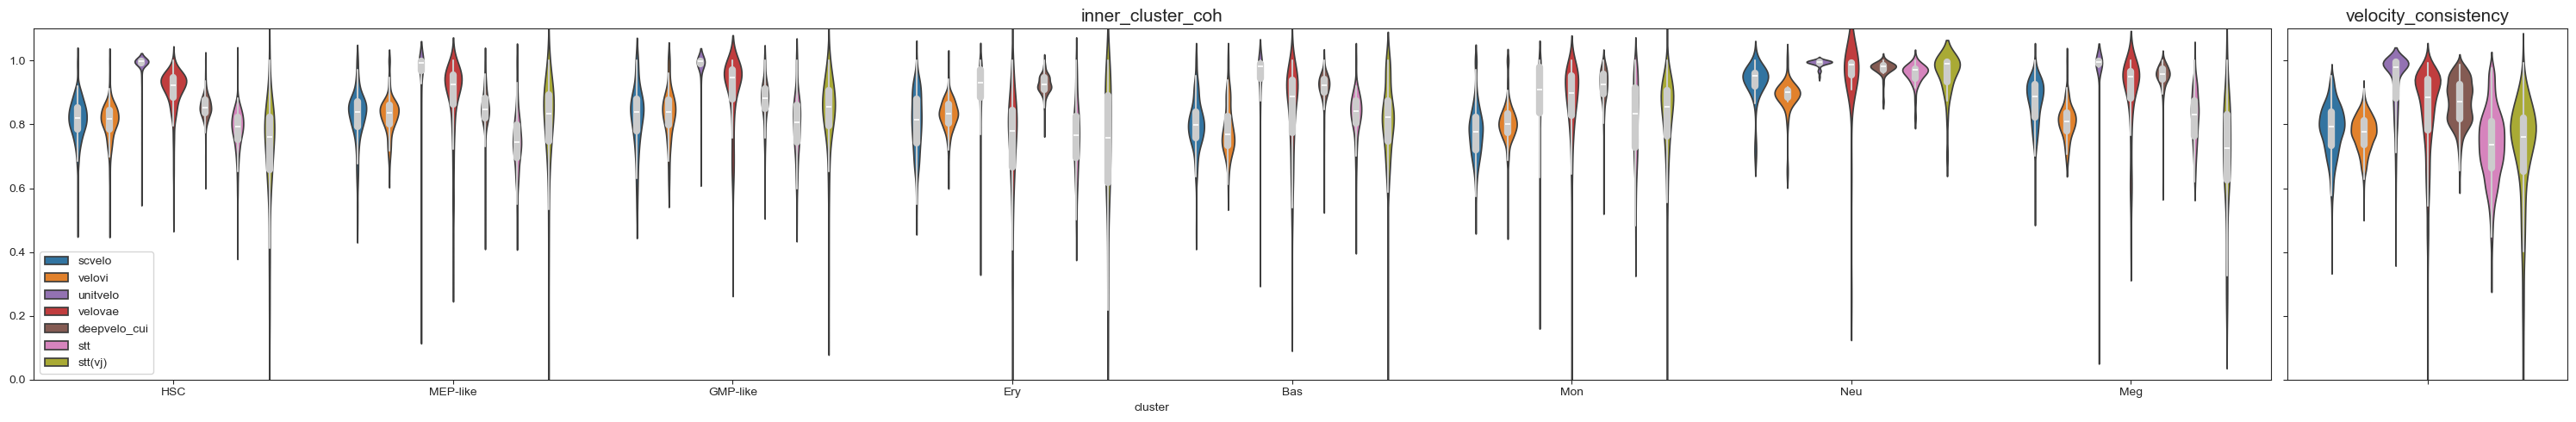

In [27]:
metric_name_iccoh = 'inner_cluster_coh'
basis = 'umap' # it does not matter
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']

# for data in datas:
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        # metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_iccoh}_{basis}_{model_name}_velocity.pkl'
        metric_file = f'../logs/{model}/{dataset}/{metric_name_iccoh}_{basis}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        result[model] = metric[cluster]
        if model == 'stt':
            # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
            # stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_iccoh}_{basis}_vj.pkl'
            stt_metric_file = f'../logs/{model}/{dataset}/{metric_name_iccoh}_{basis}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
    results[cluster] = result

# transform into long format
result_long = []
for cluster, result in results.items():
    for model, metric in result.items():
        for value in metric:
            result_long.append({'cluster': cluster, 'model': model, metric_name_iccoh: value})
df_long = pd.DataFrame(result_long)

metric_name_v_consist = 'velocity_consistency'
result = {}
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
    # metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_v_consist}_{basis}_{model_name}_velocity.pkl'
    metric_file = f'../logs/{model}/{dataset}/{metric_name_v_consist}_{basis}_{model_name}_velocity.pkl'
    with open(metric_file, 'rb') as f:
        metric = pkl.load(f)
    result[model] = metric
    if model == 'stt':
        # dataset_name = dataset if model != 'stt' else f'{dataset}_sc'
        # stt_metric_file = f'../logs/{model}/{dataset_name}/{data}/{metric_name_v_consist}_{basis}_vj.pkl'
        stt_metric_file = f'../logs/{model}/{dataset}/{metric_name_v_consist}_{basis}_vj.pkl'
        with open(stt_metric_file, 'rb') as f:
            stt_metric = pkl.load(f)
        result['stt(vj)'] = stt_metric

# save_dir = f'../results/result_22feb/{dataset.replace("simulate/", "")}/{data.replace("/", "-")}'
# os.makedirs(save_dir, exist_ok=True)

# subplots
n_cols = 2
fig, axs = plt.subplots(1, n_cols, figsize=(30, 5), gridspec_kw={'width_ratios': [8, 1]}, sharey=True)
sns.violinplot(x='cluster', y=metric_name_iccoh, hue='model', data=df_long, palette=model_colors, ax=axs[0], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
axs[0].set_ylim(0, 1.1)
axs[0].set_title(metric_name_iccoh, fontsize=15)
# remove y-axis label
axs[0].set_ylabel('')
# remove legend
# axs[0].get_legend().remove()
# remove legend title
axs[0].get_legend().set_title('')
sns.violinplot(y=metric_name_v_consist, hue='model', data=pd.DataFrame(result).melt(var_name='model', value_name=metric_name_v_consist), palette=model_colors, ax=axs[1], width=0.8, gap=0.2, inner_kws=dict(box_width=6, whis_width=1.5, color=".8"))
axs[1].set_ylim(0, 1.1)
axs[1].set_title(metric_name_v_consist, fontsize=15)
# remove y-axis label
axs[1].set_ylabel('')
# remove legend
axs[1].get_legend().remove()
# Adjust the legend to be outside the plot
# handles, labels = axs[0].get_legend_handles_labels()
# plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0), fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/iccoh_and_vconsist.svg')
plt.show()

**t-score**: 不分basis没有stt

In [ ]:
metric_name = 'time_score_edge'
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']

for data in datas:
    results = {}
    for cluster_edge in cluster_edges:
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {}
        for model in models:
            # metric_file = f'../logs/{data}/{model}/metric_{basis}_redo.csv'
            metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}_redo.csv'
            if not os.path.exists(metric_file):
                metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}.csv'
            metric = pd.read_csv(metric_file)
            metric.set_index('Unnamed: 0', inplace=True)
            idx_name = f'{metric_name}_pred_t_norm_{edge}'
            if idx_name in metric.index:
                t_score = metric.loc[metric.index == idx_name, '0'].values[0]
                t_score = float(t_score)
                result[model] = t_score
            if model == 'scvelo':
                scv_idx_name = f'{metric_name}_fit_t_norm_{edge}'
                if scv_idx_name in metric.index:
                    t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
                    t_score = float(t_score)
                    result['scvelo(avg)'] = t_score
        results[edge] = result

    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)

    for key, value in results.items():
        df = pd.DataFrame(list(value.items()), columns=['model', metric_name])
        plt.figure(figsize=(8, 6))
        sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
        plt.ylim(0, 1)
        plt.title(key)
        plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
        plt.show()

**spatial time consistency**
不分basis没有stt

In [ ]:
metric_name = 'spatial_time_consist'
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']
for data in datas:
    result = {}
    for model in models:
        metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}.csv'
        metric = pd.read_csv(metric_file)
        metric.set_index('Unnamed: 0', inplace=True)
        idx_name = f'{metric_name}_pred_t_norm'
        t_score = metric.loc[metric.index == idx_name, '0'].values[0]
        t_score = float(t_score)
        result[model] = t_score
        if model == 'scvelo':
            scv_idx_name = f'{metric_name}_fit_t_norm'
            t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
            t_score = float(t_score)
            result['scvelo(avg)'] = t_score
    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)
    df = pd.DataFrame(list(result.items()), columns=['model', metric_name])
    plt.figure(figsize=(8, 6))
    sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
    plt.ylim(0, 1)
    plt.savefig(f'{save_dir}/{metric_name}.svg')
    plt.show()

**velocity consistency** (pca neigh.) & **spatial velocity consistency**
不分basis

In [25]:
import numpy as np

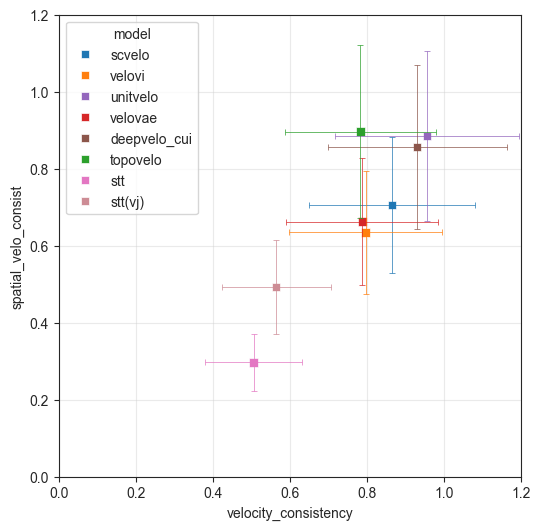

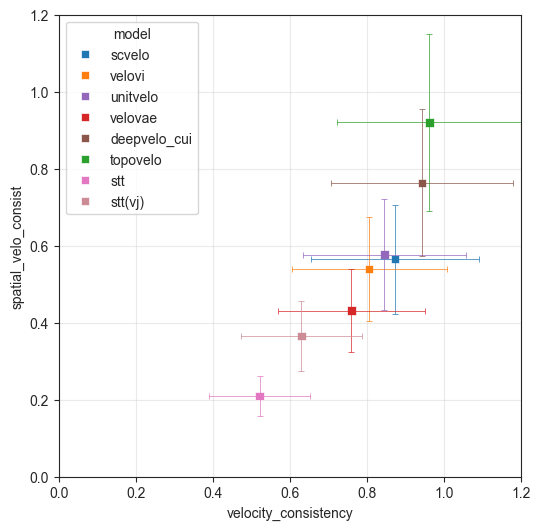

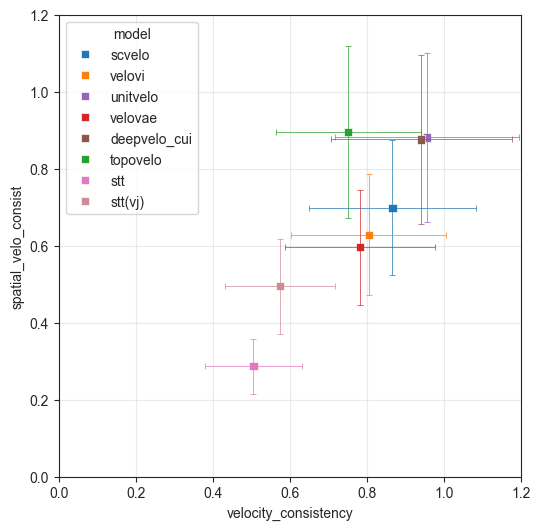

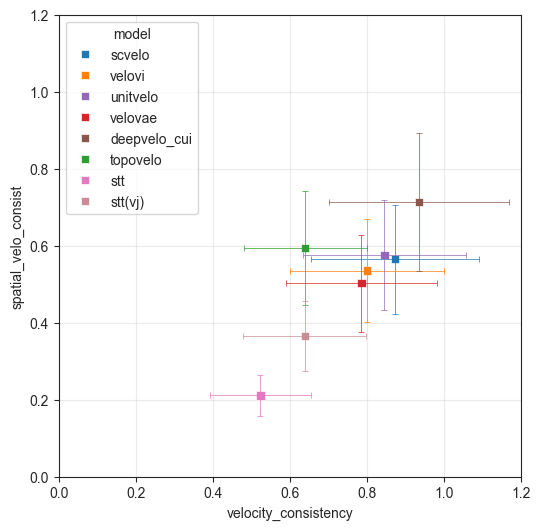

In [27]:
metric_names = ('velocity_consistency', 'spatial_velo_consist')
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
for data in datas:
    results = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        result = {}
        for metric_name in metric_names:
            metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pd.read_pickle(f)
            result[metric_name] = metric
        results[model] = result
        if model == 'stt':
            result = {}
            for metric_name in metric_names:
                stt_metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    metric = pd.read_pickle(f)
                result[metric_name] = metric
            results['stt(vj)'] = result
    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)

    import numpy as np
    keys = []
    velocity_consistency_means = []
    spatial_velo_consist_means = []
    velocity_consistency_stds = []
    spatial_velo_consist_stds = []
    for key, value in results.items():
        keys.append(key)
        velocity_consistency_means.append(np.mean(value['velocity_consistency']))
        spatial_velo_consist_means.append(np.mean(value['spatial_velo_consist']))
        velocity_consistency_stds.append(np.mean(value['velocity_consistency']))
        spatial_velo_consist_stds.append(np.mean(value['spatial_velo_consist']))
    df = pd.DataFrame({'model': keys, 'velocity_consistency': velocity_consistency_means, 'spatial_velo_consist': spatial_velo_consist_means})
    plt.figure(figsize=(8, 6))
    plt.xlim(0, 1.2)
    plt.ylim(0, 1.2)
    plt.gca().set_aspect('equal')
    sns.scatterplot(data=df, x='velocity_consistency', y='spatial_velo_consist', hue='model', palette=model_colors, marker='s')
    for i in range(df.shape[0]):
        plt.errorbar(df['velocity_consistency'][i], df['spatial_velo_consist'][i], xerr=0.25*velocity_consistency_stds[i], yerr=0.25*spatial_velo_consist_stds[i], fmt='none', color=model_colors[df['model'][i]], 
                    capsize=2, capthick=0.5, elinewidth=0.5)
    plt.grid(alpha=0.4)
    plt.savefig(f'{save_dir}/velocity_consistency_vs_spatial_velo_consist.svg')
    plt.show()
